# 2D Nuclei segmentation pepline

In [3]:
#required libraries
import matplotlib.pyplot as plt
import glob # for working with multiple files
import skimage as ski
import skimage.io as io
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from scipy.ndimage import gaussian_filter
from scipy.ndimage import distance_transform_edt, label
from skimage.color import label2rgb
import os


In [4]:
print(os.getcwd()) # Print the current working directory

/Users/ngocdiep/Classical nuclei segmentation/Code


/var/folders/k5/q1x8ytkx367ds0kgvz960wz00000gn/T/ipykernel_75692/1437720819.py:13: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(images_x10y10[5])
/Users/ngocdiep/Classical nuclei segmentation/.venv/lib/python3.11/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


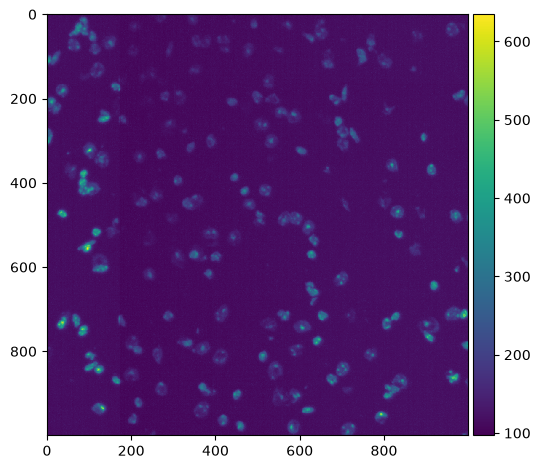

In [5]:
#Create a figure that incorporates all runs (c1 - c4) of one tile as subplots.
#Create a list of file for all images of tile X10_Y10
x10y10 = glob.glob("../Data/selected-tiles/out_opt_flow_registered_X10_Y10_*.tif") 
#.. to go back to the parent directory, then go to Data/selected-tiles

#Sort again to have a right c01 -> c04 order
x10y10 = sorted(x10y10)
    
#Read all imgaes into a list
images_x10y10 = [io.imread(img) for img in x10y10]

# Display the first image as a check at dapi channel
io.imshow(images_x10y10[5])

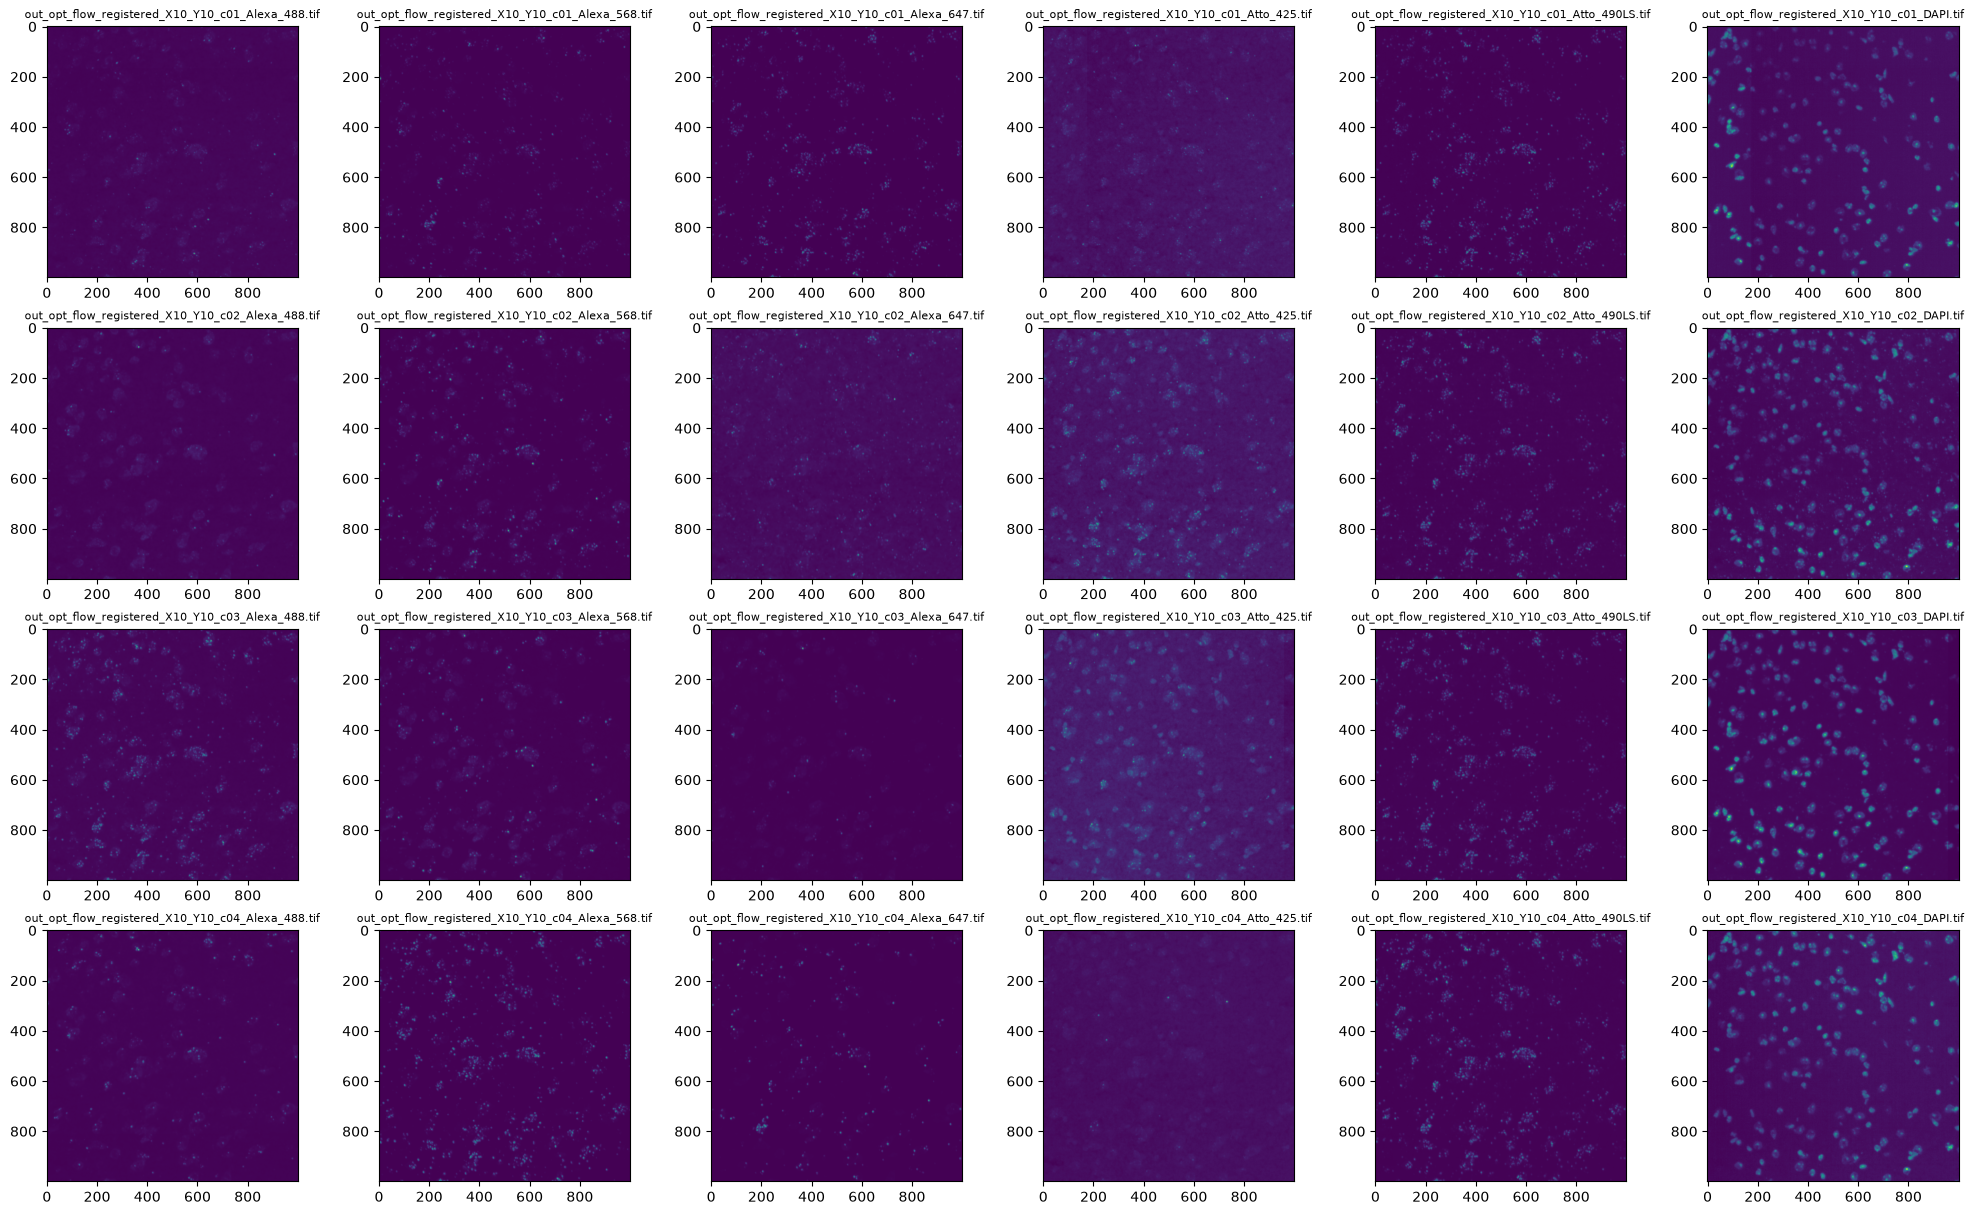

In [6]:
#Create a figure that incorporates all runs (c1 - c4) of one tile as subplots.
fig, axs = plt.subplots(4, 6, figsize=(25, 15))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(images_x10y10[i])
    filename = os.path.basename(x10y10[i])
    ax.set_title(filename, fontsize=8)
plt.show()

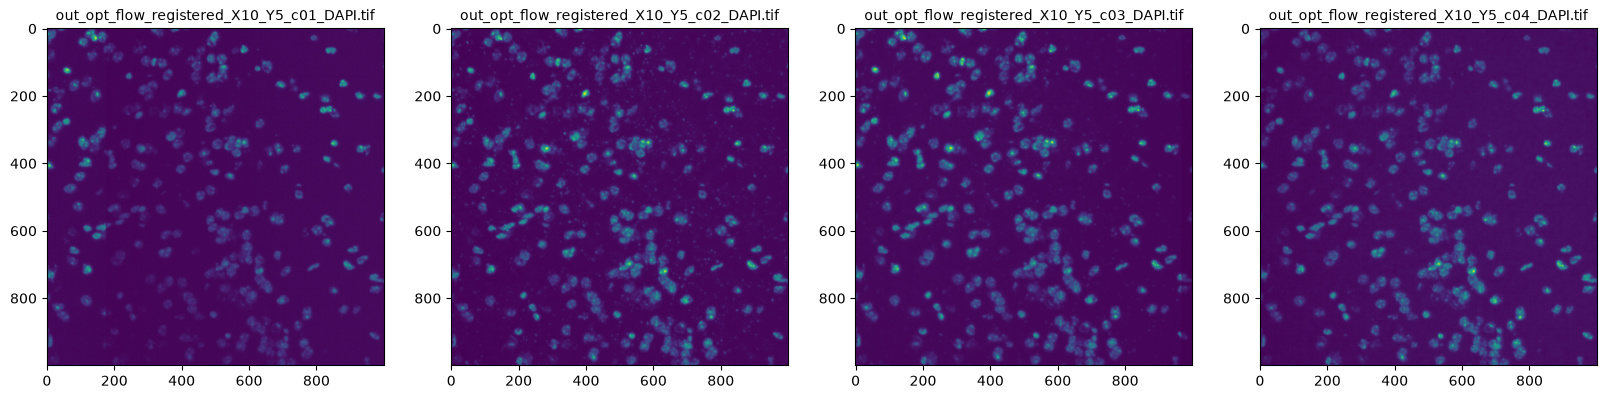

In [7]:
#create a list of files for all DAPI chanels across one tiles (x10y5)
dapi_x10y5 = glob.glob("../Data/selected-tiles/out_opt_flow_registered_X10_Y5_*_DAPI.tif")

#sort again to have a right c01 -> c04 order
dapi_x10y5 = sorted(dapi_x10y5)

#read all imgaes into a list
images_dapi = [ski.io.imread(img) for img in dapi_x10y5]

#Create a figure that incorporates dapi for all runs (c1 - c4) of one tile.
fig, axs = plt.subplots(1, 4, figsize=(20, 25))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(images_dapi[i])
    filename = os.path.basename(dapi_x10y5[i])
    ax.set_title(filename, fontsize=10)
plt.show()

## 1. Histogram: shows the distribution of pixel intensities

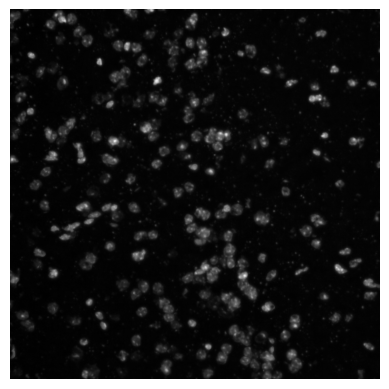

In [8]:
# read the first image of dapi channel for tile x10y5
im = io.imread(dapi_x10y5[1])  
# Show the image
plt.imshow(im, cmap='gray')
plt.axis(False)
plt.show()

In [9]:
# calculating statistics
print(f'Mean:     {im.mean()}')
print(f'Minimum:  {im.min():.1f}')
print(f'Maximum:  {im.max():.2f}')
print(f'Std.dev.: {im.std():.3f}')
print(im.shape) #show the dimensions of image array (y, x)- (height, width)
print(im.dtype) #show the data type of image array

Mean:     203.892471
Minimum:  121.0
Maximum:  1670.00
Std.dev.: 132.461
(1000, 1000)
uint16


Shape before flatten(): (1000, 1000)
Shape after flatten(): (1000000,)


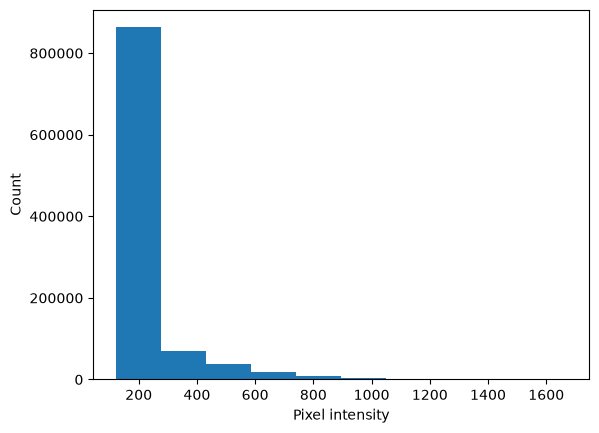

In [10]:
#generating histograms
print(f'Shape before flatten(): {im.shape}')
im_flat = im.flatten() # create a 1D list of values as histogram function requires 1D array
print(f'Shape after flatten(): {im_flat.shape}')

plt.hist(im_flat)
plt.xlabel("Pixel intensity")
plt.ylabel("Count")
plt.savefig("../results/histogram.png") #save the histogram figure to results folder
plt.show()



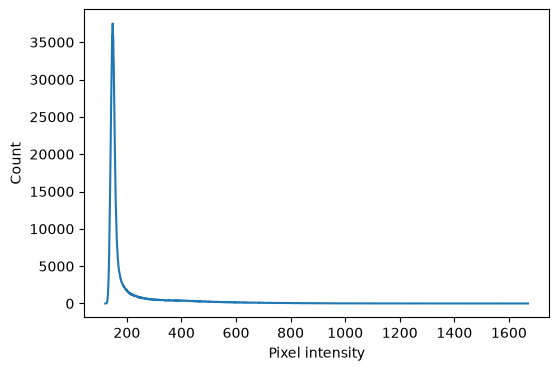

In [11]:
# histogram with skimage
hist, hist_centers = ski.exposure.histogram(im)
# Plot histogram
plt.figure(figsize=(6,4))
plt.plot(hist_centers, hist)
plt.xlabel("Pixel intensity")
plt.ylabel("Count")
plt.show()

## 2. Thresholding: separates foreground from background based on pixel intensity


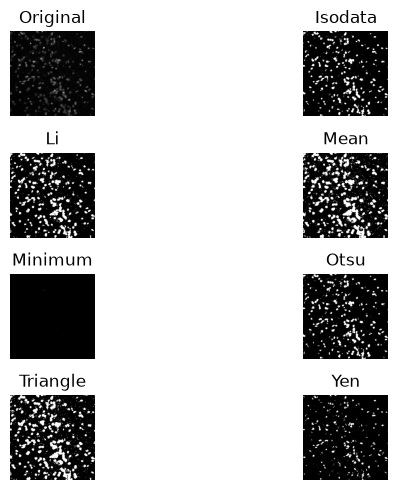

In [12]:
# try all threshold method
fig, ax = ski.filters.try_all_threshold(im, figsize=(8, 5), verbose=False)
plt.show()

In [13]:
#Apply Gaussian filter to smooth the image before thresholding
smooth = gaussian_filter(im, sigma=1)

#Compute global threhold with Otsu method
thresh= ski.filters.threshold_otsu(smooth)  
print("the threshold value:",thresh)

the threshold value: 355


## 3. Binary image where 0 = background, 1 = object (forground)

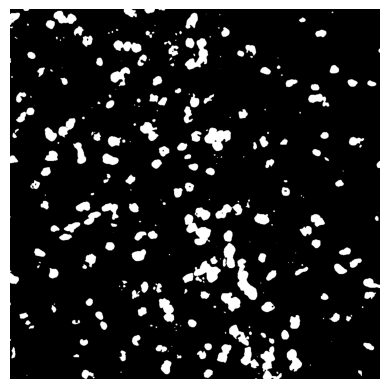

In [14]:
#create binary image
#If a pixel value is greater than the threshold → it becomes True (white/ foreground)
binary_nuclei = smooth > thresh 

# Plot
plt.imshow(binary_nuclei, cmap='gray')
plt.axis('off')
#plt.title("Binary mask")
plt.show()

/var/folders/k5/q1x8ytkx367ds0kgvz960wz00000gn/T/ipykernel_75692/22415478.py:2: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_nuclei = ski.morphology.remove_small_objects(binary_nuclei, min_size=100)


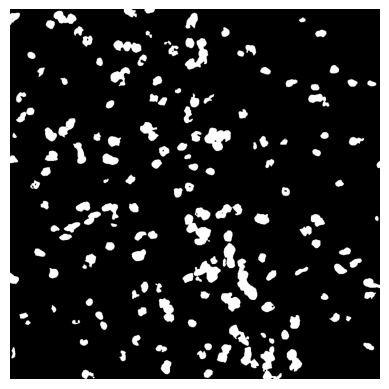

In [15]:
# Remove small objects smaller than 100 pixels
cleaned_nuclei = ski.morphology.remove_small_objects(binary_nuclei, min_size=100)
plt.imshow((cleaned_nuclei),cmap='gray')
plt.axis(False)
plt.show()

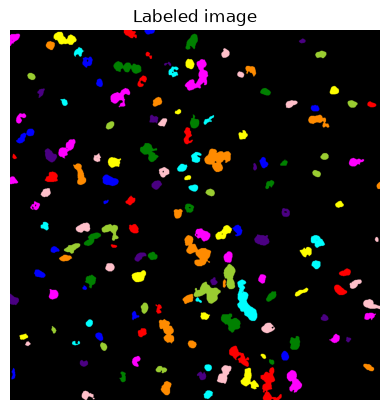

In [16]:
# Label the binary mask
labels = ski.measure.label(cleaned_nuclei)
#Two pixels are connected when they are neighbors and have the same value
plt.imshow(label2rgb(labels))
#Return an RGB image where color-coded labels are painted over the image.
plt.axis(False)
plt.title("Labeled image")
plt.show()

## 4. Distance transform: Distance from every foreground pixcel (1) to the nearest background (0) 


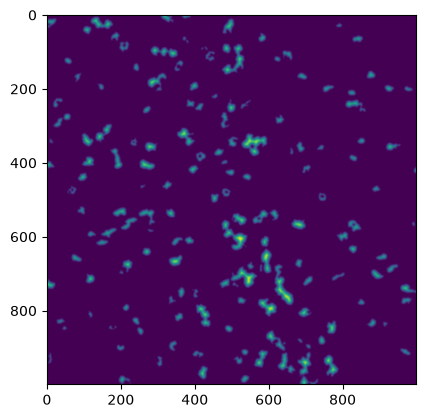

In [17]:
distance = distance_transform_edt(cleaned_nuclei) 

#Distance map should be smoothed before peak detection to prevents over-segmentation
distance = gaussian_filter(distance, sigma=1) 
plt.imshow(distance)
plt.show()

## 5. Watershed: cuts binary blots using peaks from distance map

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


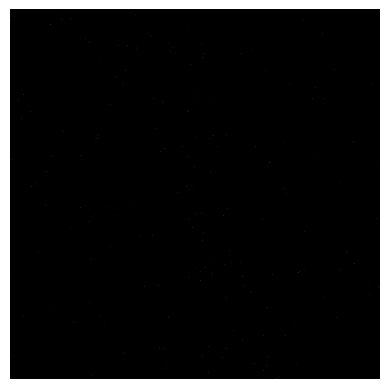

In [18]:
#find local maximal
local_maxi = ski.morphology.local_maxima(distance)  
#the maxima is center of the nuclei- TRUE value, the opposit would be marker/seeds
print(local_maxi)
#label the maxima to create markers
markers= ndi.label(local_maxi) [0] # pick marker at 0- False value
print(markers)
#apply watershed
labels = ski.segmentation.watershed(-distance,markers= markers, mask=cleaned_nuclei) #water goes from low -> high region

plt.imshow(label2rgb(markers))
plt.axis("off")
plt.show()

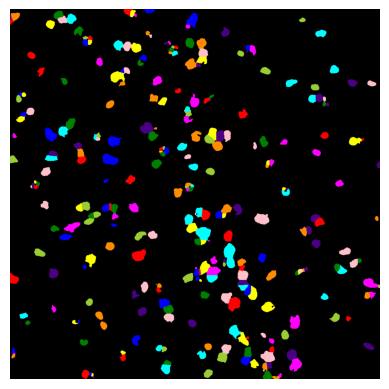

Number of nuclei: 297


In [19]:
plt.imshow(label2rgb(labels))
plt.axis(False)
plt.show()
print("Number of nuclei:", labels.max())

/var/folders/k5/q1x8ytkx367ds0kgvz960wz00000gn/T/ipykernel_75692/950391302.py:8: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_nuclei = ski.morphology.remove_small_objects(binary_nuclei, min_size=min_size)# remove small object


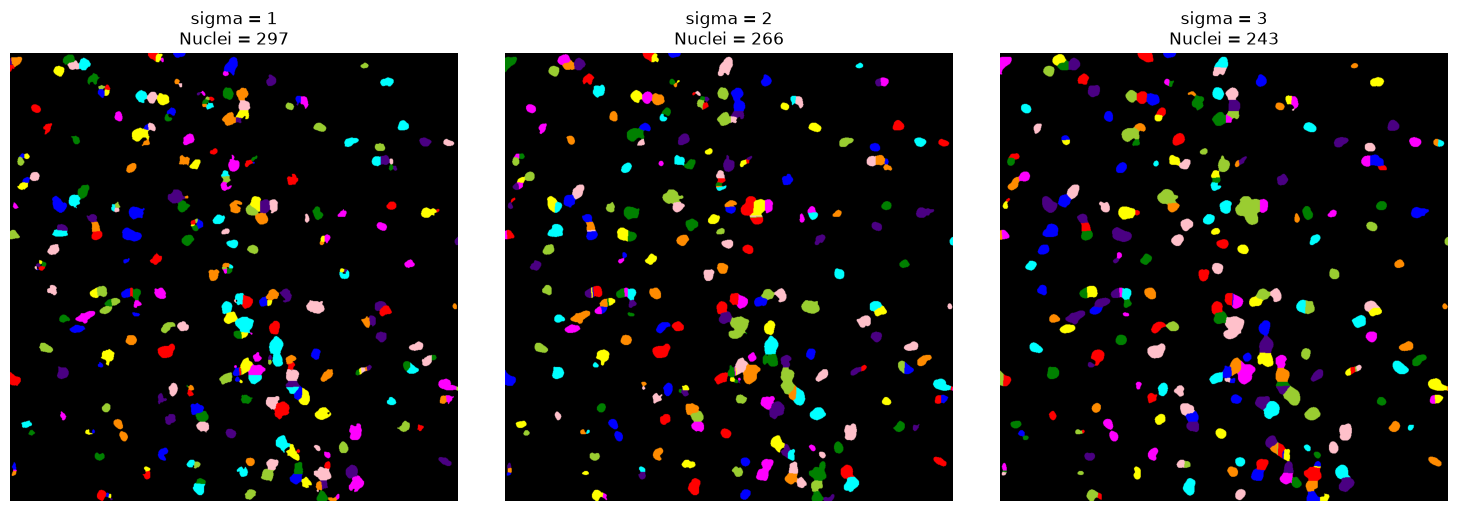

In [20]:
# Create a figure to compare effect of different smoothing parameters on segmentation results
def nuclei_segmentation (im, sigma_smooth=1, 
                         min_size=100, sigma_dist=1, show=False):
    
    smooth = gaussian_filter(im, sigma=sigma_smooth) #smothing
    thresh = ski.filters.threshold_otsu(smooth) #global Otsu threshold 
    binary_nuclei = smooth > thresh #binary mask
    cleaned_nuclei = ski.morphology.remove_small_objects(binary_nuclei, min_size=min_size)# remove small object
    distance = distance_transform_edt(cleaned_nuclei) #distance transform
    distance = gaussian_filter(distance, sigma=sigma_dist)
    local_maxi = ski.morphology.local_maxima(distance)
    markers = ndi.label(local_maxi)[0] #markers from local maxima 
    labels = ski.segmentation.watershed(-distance, markers=markers, mask=cleaned_nuclei)
    return labels


sigmas = [1, 2, 3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, sigma in zip(axes, sigmas):

    labels = nuclei_segmentation(im, sigma_smooth=sigma)
    num_nuclei = labels.max()

    # clean label visualization
    ax.imshow(label2rgb(labels, bg_label=0))
    ax.set_title(f'sigma = {sigma}\nNuclei = {num_nuclei}')
    ax.axis('off')

plt.tight_layout()
plt.savefig("../Results/Sigma_effect.png")
plt.show()



In [21]:
# create a function for analysis: smoothing -> thresholding -> filtering -> distacemap -> markers -> watershed -> counting

def nuclei_segmentation (im, sigma_smooth=1, 
                         min_size=100, sigma_dist=1, show=False):
    
    smooth = gaussian_filter(im, sigma=sigma_smooth) #smothing
    thresh = ski.filters.threshold_otsu(smooth) #global Otsu threshold 
    binary_nuclei = smooth > thresh #binary mask
    cleaned_nuclei = ski.morphology.remove_small_objects(binary_nuclei, min_size=min_size)# remove small object
    distance = distance_transform_edt(cleaned_nuclei) #distance transform
    distance = gaussian_filter(distance, sigma=sigma_dist)
    local_maxi = ski.morphology.local_maxima(distance)
    markers = ndi.label(local_maxi)[0] #markers from local maxima 
    labels = ski.segmentation.watershed(-distance, markers=markers, mask=cleaned_nuclei)
    
    if show:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(im) #Original image
        axes[0].set_title("Original DAPI")
        axes[0].axis("off")

        axes[1].imshow(cleaned_nuclei, cmap='gray') #Binary mask
        axes[1].set_title("Binary Mask")
        axes[1].axis("off")

        axes[2].imshow(label2rgb(labels)) #labeling 
        axes[2].set_title(f"Segmented Nuclei ({labels.max()} nuclei)")
        axes[2].axis("off") 

        plt.tight_layout()
        plt.savefig("../results/segmentation_results2.png") 
        plt.show()

    return {
        "binary_nuclei": binary_nuclei,
        "cleaned_nuclei": cleaned_nuclei,
        "distance_map": distance,
        "markers": markers,
        "labels": labels
    }

/var/folders/k5/q1x8ytkx367ds0kgvz960wz00000gn/T/ipykernel_75692/263592377.py:9: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_nuclei = ski.morphology.remove_small_objects(binary_nuclei, min_size=min_size)# remove small object


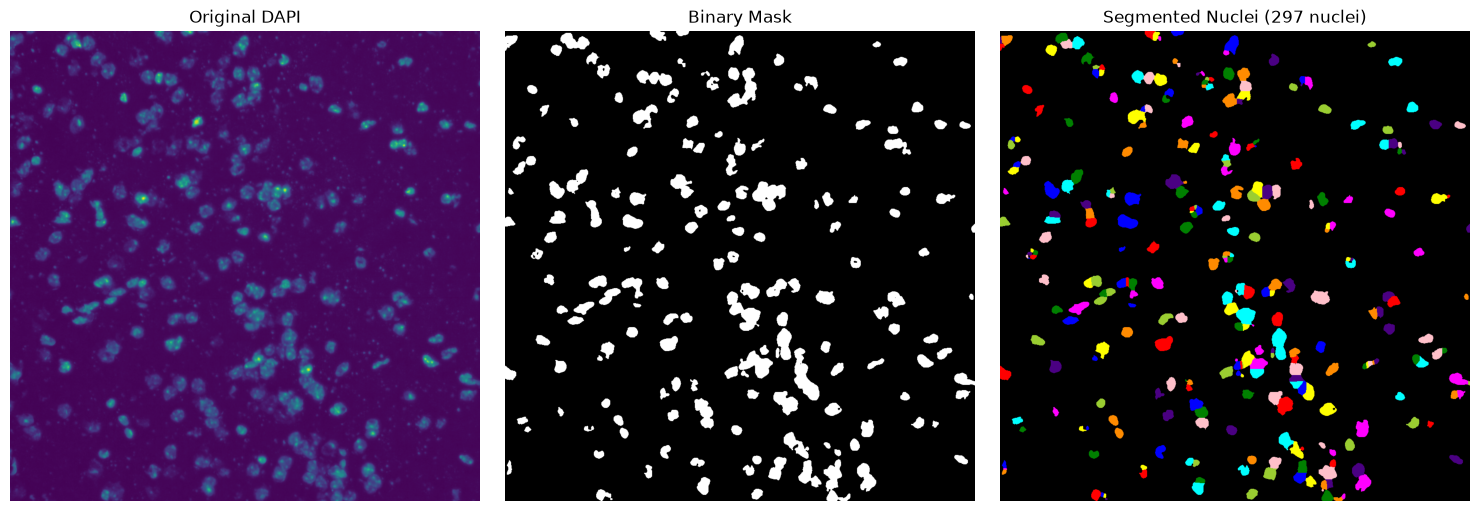

Final nuclei count: 297


In [22]:
#making diagnosis figure, including the orginal, binary mask & final labeling 
result = nuclei_segmentation(im, show=True)
print("Final nuclei count:", result["labels"].max())

/var/folders/k5/q1x8ytkx367ds0kgvz960wz00000gn/T/ipykernel_75692/263592377.py:9: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_nuclei = ski.morphology.remove_small_objects(binary_nuclei, min_size=min_size)# remove small object


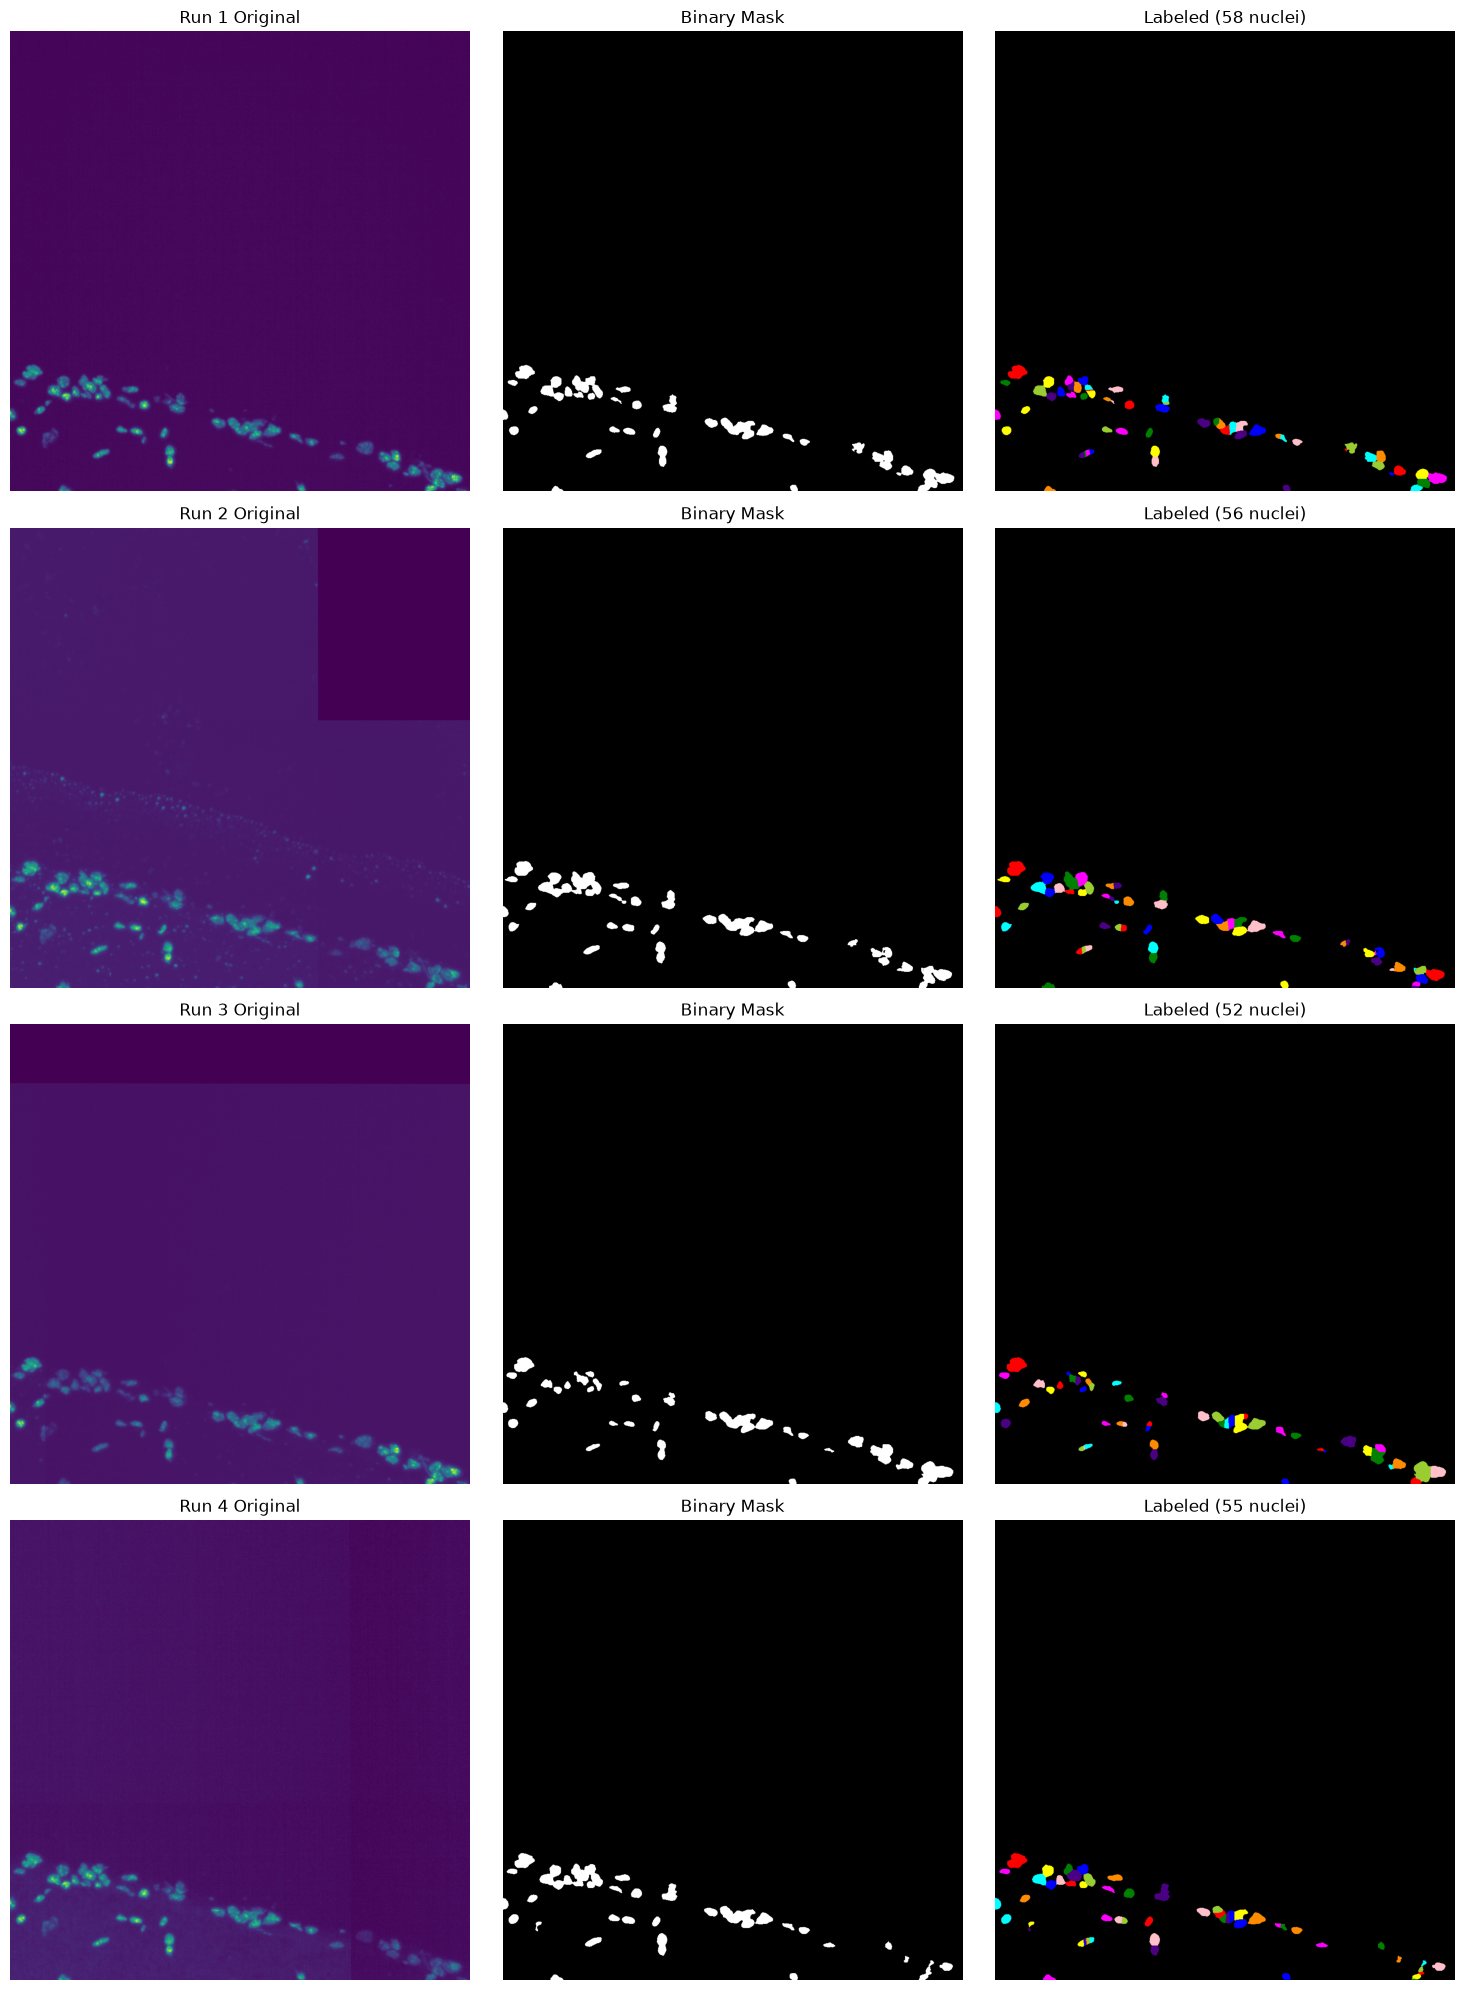

In [31]:
#loop through 4 runs in 1 FOV
#get four dapi runs
dapi_x17y0 = sorted(glob.glob("../Data/selected-tiles/out_opt_flow_registered_X17_Y0_*_DAPI.tif"))
#read all imgaes into a list
images_dapi = [ski.io.imread(img) for img in dapi_x17y0]

# Loop through all runs and segment nuclei
results = []  # store results of each run
for i, img in enumerate(images_dapi): #Loop through all DAPI image
    res = nuclei_segmentation(img, show=False)  # do not show separate figure for each run
    results.append(res) #Adds the dictionary res to the results list.
    
# Segment nuclei using the function
fig, axs = plt.subplots(4, 3, figsize=(15, 20)) 
for i, res in enumerate(results):
    # Original
    axs[i, 0].imshow(images_dapi[i])
    axs[i, 0].set_title(f"Run {i+1} Original")
    axs[i, 0].axis('off')

    # Binary mask
    axs[i, 1].imshow(res["cleaned_nuclei"], cmap='gray')
    axs[i, 1].set_title("Binary Mask")
    axs[i, 1].axis('off')

    # Labeled nuclei
    axs[i, 2].imshow(label2rgb(res["labels"]))
    axs[i, 2].set_title(f"Labeled ({res['labels'].max()} nuclei)")
    axs[i, 2].axis('off')

plt.tight_layout()
plt.savefig("../results/results1.png") 
plt.show()

## 6. Analyzed again with different parameters

In [24]:
from skimage import morphology
from skimage import filters
from skimage import measure 
from skimage import feature
from skimage import segmentation
from skimage import img_as_float
from scipy.ndimage import distance_transform_edt, binary_fill_holes
from scipy import ndimage as ndi
from scipy.ndimage import label
import matplotlib.pyplot as plt
import skimage.io as io # skimage has good TIFF support
from skimage.color import label2rgb
import numpy as np
import os

the threshold value: 0.005366496377402416


/var/folders/k5/q1x8ytkx367ds0kgvz960wz00000gn/T/ipykernel_75692/3750301512.py:12: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  large_objects = morphology.remove_small_objects(img_binary, min_size=100, connectivity=2)


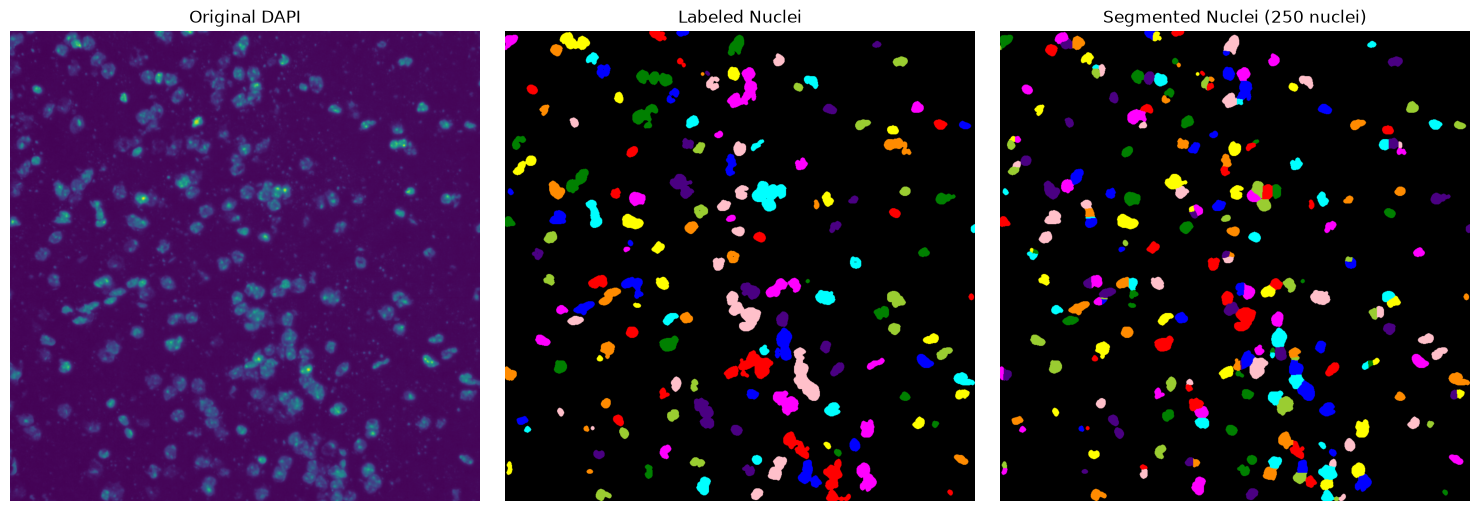

Number of nuclei: 250


In [32]:
img = io.imread ("../Data/selected-tiles/out_opt_flow_registered_X10_Y5_c02_DAPI.tif")
img = img_as_float(img) 

#try threshold with filter before it
filter = filters.gaussian(img, sigma= 1, mode='constant') #sigma: standard deviation around the mean, mode: method to add data in edges
thres = filters.threshold_otsu(filter)
print("the threshold value:",thres)

#create binary image
img_binary = filter >= thres 

large_objects = morphology.remove_small_objects(img_binary, min_size=100, connectivity=2)
#img_open = morphology.isotropic_opening(large_objects, radius=3) #erosion followed by a dilation
img_erosion = morphology.isotropic_erosion(large_objects, radius= 3)
img_dilation = morphology.isotropic_dilation(img_erosion, radius = 4)
lab, n = label(img_dilation)

img_edt = distance_transform_edt(img_dilation) 
img_edt = filters.gaussian(img_edt, sigma = 1.85, mode = "mirror")  

local_mini = morphology.local_minima(-img_edt, connectivity=2, indices=False, allow_borders=True)  
#local_mini = morphology.remove_small_objects(local_mini, 0.5)

h_img = morphology.h_minima(-img_edt, h=0.5) #Determine all minima of the image with depth >= h.
seeds = local_mini | h_img
lab_seeds, n = label(seeds)

img_seg = segmentation.watershed(-img_edt,markers= lab_seeds, mask=img_dilation) #water goes from low -> high region

#diagnose image
fig, axes = plt.subplots (1,3, figsize =(15,5))

axes[0].imshow(img)
axes[0].set_title("Original DAPI")
axes[0].axis('off')

axes[1].imshow(label2rgb(lab))
axes[1].set_title("Labeled Nuclei")
axes[1].axis('off')

axes[2].imshow(label2rgb(img_seg))
axes[2].set_title(f"Segmented Nuclei ({img_seg.max()} nuclei)")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("../Results/results2.png")
plt.show()
print("Number of nuclei:", img_seg.max())



the threshold value: 0.0070860863065596085


/var/folders/k5/q1x8ytkx367ds0kgvz960wz00000gn/T/ipykernel_75692/986167619.py:12: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  large_objects = morphology.remove_small_objects(img_binary, min_size=100, connectivity=2)


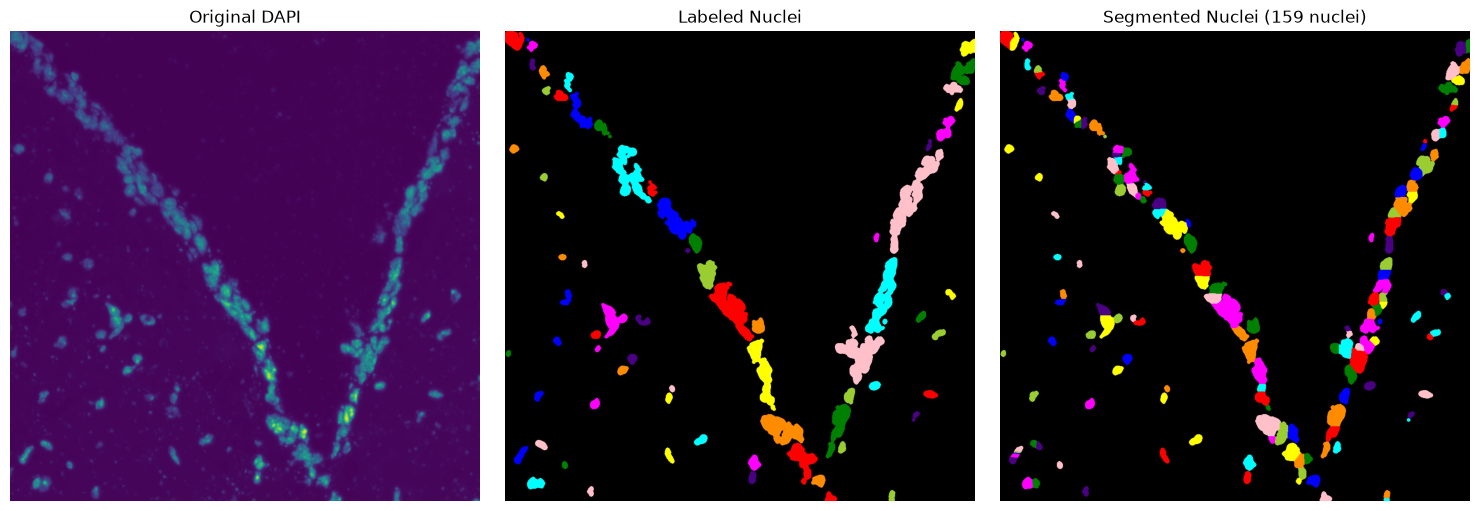

Number of nuclei: 159


<Figure size 640x480 with 0 Axes>

In [33]:
img = io.imread ("../Data/selected-tiles/out_opt_flow_registered_X10_Y2_c02_DAPI.tif")
img = img_as_float(img) 

#try threshold with fillter before it
fillter = filters.gaussian(img, sigma= 1, mode='constant') #sigma: standard deviation around the mean, mode: method to add data in edges
thres = filters.threshold_otsu(fillter)
print("the threshold value:",thres)

#create binary image
img_binary = fillter >= thres 

large_objects = morphology.remove_small_objects(img_binary, min_size=100, connectivity=2)
#img_open = morphology.isotropic_opening(large_objects, radius=3) #erosion followed by a dilation
img_erosion = morphology.isotropic_erosion(large_objects, radius= 3)
img_dilation = morphology.isotropic_dilation(img_erosion, radius = 4)
lab, n = label(img_dilation)

img_edt = distance_transform_edt(img_dilation) 
img_edt = filters.gaussian(img_edt, sigma = 1.85, mode = "mirror")  

local_mini = morphology.local_minima(-img_edt, connectivity=2, indices=False, allow_borders=True)  
#local_mini = morphology.remove_small_objects(local_mini, 0.5)

h_img = morphology.h_minima(-img_edt, h=0.5) #Determine all minima of the image with depth >= h.
seeds = local_mini | h_img
lab_seeds, n = label(seeds)

img_seg = segmentation.watershed(-img_edt,markers= lab_seeds, mask=img_dilation) #water goes from low -> high region

#diagnose image
fig, axes = plt.subplots (1,3, figsize =(15,5))

axes[0].imshow(img)
axes[0].set_title("Original DAPI")
axes[0].axis('off')

axes[1].imshow(label2rgb(lab))
axes[1].set_title("Labeled Nuclei")
axes[1].axis('off')

axes[2].imshow(label2rgb(img_seg))
axes[2].set_title(f"Segmented Nuclei ({img_seg.max()} nuclei)")
axes[2].axis('off')

plt.tight_layout()
plt.show()
plt.savefig("../Results/results3.png")
print("Number of nuclei:", img_seg.max())